In [1]:
import numpy as  np 
import os 
from PIL import Image
from torchvision.transforms import transforms as T 
from matplotlib import pyplot as plt 
import cv2 

In [2]:
arr = plt.imread("/home/kathy/dataset/submit_a/R_target1/patient-2-4_label.gz_14.png")

In [3]:
arr.shape 

(800, 600, 4)

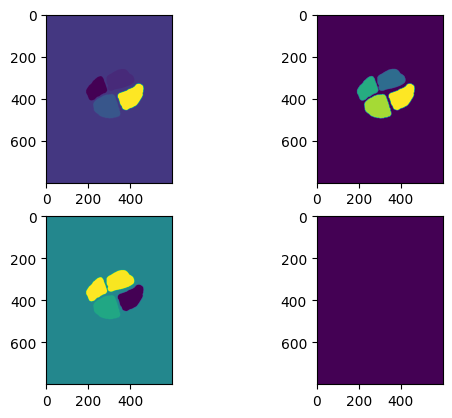

In [4]:
fig, axes = plt.subplots(2, 2)
axes[0, 0].imshow(arr[..., 0] )
axes[0, 1].imshow(arr[..., 1] )
axes[1, 0].imshow(arr[..., 2] )
axes[1, 1].imshow(arr[..., 3] )

In [5]:
np.unique(arr[..., 0])

array([0.1254902 , 0.22745098, 0.26666668, 0.35686275, 0.99215686],
      dtype=float32)

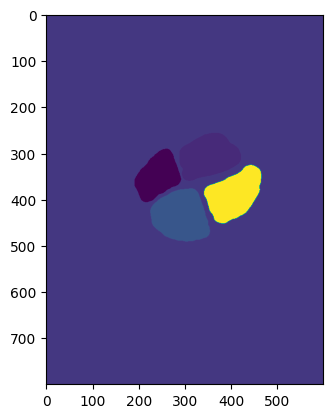

In [11]:
plt.imshow(arr[..., 0])

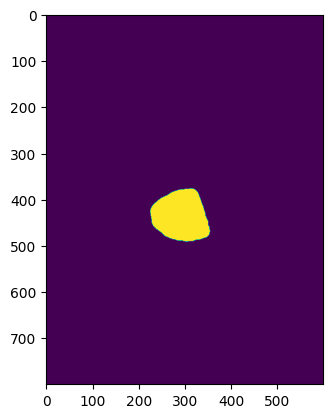

In [16]:
plt.imshow(np.where( arr[..., 0] == 0.35686275, arr[..., 0], 0))

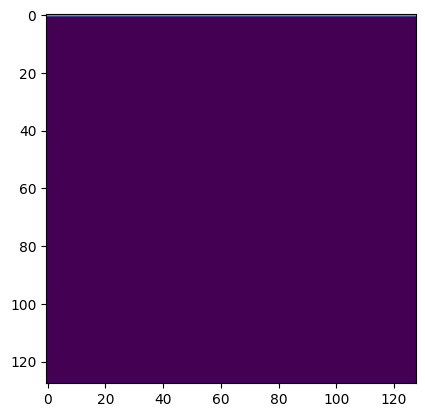

In [9]:
demo = np.zeros((128, 128))

demo[:32, :] == 0.1254902
demo[0, :] = 0.26666668
demo[32:64, :] == 0.22745098
demo[64:96, :] == 0.35686275
demo[96:, :] == 0.99215686
plt.imshow(demo * 255)

In [10]:
demo.shape 

(128, 128)

In [20]:
[(arr[..., 0] == i ).sum() for i in np.unique(arr[..., 0])]

[7314, 9796, 441958, 11045, 9887]

In [21]:
np.unique(arr[..., 0])

array([0.1254902 , 0.22745098, 0.26666668, 0.35686275, 0.99215686],
      dtype=float32)

In [23]:
(arr == 0.1254902).sum()

7314

In [14]:
base_dir = "/home/kathy/dataset/submit/images/"
image_file_list =[]
target_file_list = []
for folder in os.listdir(base_dir):
    demo_dir = base_dir + folder + "/"
    for file in os.listdir(demo_dir):
        image_file = demo_dir + file 
        target_file = image_file.replace("images", "labels")
        image_file_list.append(image_file)
        target_file_list.append(target_file)


In [17]:
len(image_file_list), len(target_file_list)


['/home/kathy/dataset/submit/images/spleen_25.gz/75.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/46.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/62.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/33.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/34.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/48.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/66.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/1.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/71.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/63.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/72.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/14.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/15.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/26.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/11.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/70.png',
 '/home/kathy/dataset/submit/images/spleen_25.gz/31.png',
 '/home/kathy/d

In [31]:
for (source_file, target_file) in zip(image_file_list, target_file_list):
    target = plt.imread(target_file)
    
    if ((target != 0).sum() > 1000):
    
        source = cv2.imread(source_file, cv2.IMREAD_GRAYSCALE)
        target_path = "/home/kathy/dataset/submit/clean/labels/" + "_".join(target_file.split("/")[-2:])
        source_path = "/home/kathy/dataset/submit/clean/images/" + "_".join(source_file.split("/")[-2:])
        plt.imsave(target_path, target)
        cv2.imwrite(source_path, source)

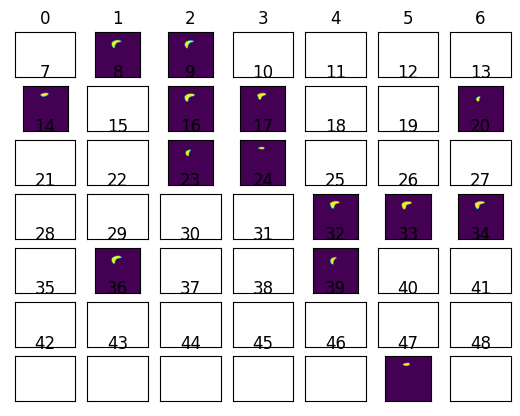

In [12]:
fig, axes = plt.subplots(7, 7)
for i in range(49):
    ax = axes.flatten()[i]
    arr = plt.imread(target_file_list[i])
    if ((arr != 0).sum() > 1000):
        ax.imshow(arr)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(str(i))

In [11]:
arr.shape 

(512, 512)

In [28]:
"/home/kathy/dataset/submit/clean/images/" + "_".join(image_file_list[0].split("/")[-2:])

'/home/kathy/dataset/submit/clean/images/spleen_25.gz_75.png'

In [25]:
lis = '/home/kathy/dataset/submit/images/spleen_25.gz/75.png'.split("/")
lis.insert(5, 'clean')
"/".join(lis)

'/home/kathy/dataset/submit/clean/images/spleen_25.gz/75.png'